<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/Unsupervised_ML_Synthetic_DataModeling_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

np.random.seed(42)

In [25]:
n1, n2, n3 = 80, 90, 70

group1 = pd.DataFrame({
    "attendance_rate": np.random.normal(95, 2.5, n1),
    "homework_completion": np.random.normal(94, 3, n1),
    "quiz_average": np.random.normal(91, 4, n1),
    "discussion_posts": np.random.normal(9, 2, n1),
    "login_days": np.random.normal(6.2, 0.5, n1),
    "missing_assignments": np.random.normal(0.5, 0.7, n1),
    "behavior_flags": np.random.normal(0.3, 0.5, n1),
})

group2 = pd.DataFrame({
    "attendance_rate": np.random.normal(84, 4, n2),
    "homework_completion": np.random.normal(78, 6, n2),
    "quiz_average": np.random.normal(76, 6, n2),
    "discussion_posts": np.random.normal(5, 2, n2),
    "login_days": np.random.normal(4.8, 0.8, n2),
    "missing_assignments": np.random.normal(2.5, 1.2, n2),
    "behavior_flags": np.random.normal(1.0, 0.8, n2),
})

group3 = pd.DataFrame({
    "attendance_rate": np.random.normal(67, 7, n3),
    "homework_completion": np.random.normal(58, 10, n3),
    "quiz_average": np.random.normal(61, 9, n3),
    "discussion_posts": np.random.normal(2.5, 1.5, n3),
    "login_days": np.random.normal(3.0, 1.0, n3),
    "missing_assignments": np.random.normal(5.5, 2.0, n3),
    "behavior_flags": np.random.normal(2.5, 1.0, n3),
})

students = pd.concat([group1, group2, group3], ignore_index=True)

outliers = pd.DataFrame({
    "attendance_rate": [45, 99, 50, 88],
    "homework_completion": [20, 40, 95, 10],
    "quiz_average": [30, 98, 35, 92],
    "discussion_posts": [0, 1, 14, 0],
    "login_days": [1.0, 1.5, 7.0, 0.8],
    "missing_assignments": [11, 8, 0, 12],
    "behavior_flags": [6, 0, 5, 7],
})

students = pd.concat([students, outliers], ignore_index=True)

students['attendance_rate'] = students['attendance_rate'].clip(0, 100)
students['homework_completion'] = students['homework_completion'].clip(0, 100)
students['quiz_average'] = students['quiz_average'].clip(0, 100)
students['discussion_posts'] = students['discussion_posts'].clip(0).round()
students['login_days'] = students['login_days'].clip(0, 7)
students['missing_assignments'] = students['missing_assignments'].clip(0).round()
students['behavior_flags'] = students['behavior_flags'].clip(0).round()

students['student_id'] = [f"S{i:03d}" for i in range(1, len(students) + 1)]

students = students[["student_id", "attendance_rate", "homework_completion", "quiz_average",
                     "discussion_posts", "login_days", "missing_assignments",
                     "behavior_flags"]]

students.head()

,student_id,attendance_rate,homework_completion,quiz_average,discussion_posts,login_days,missing_assignments,behavior_flags
0,S001,96.241785,93.340984,87.101273,7.0,6.248498,0.0,0.0
1,S002,94.654339,95.071338,94.148338,9.0,6.497579,0.0,0.0
2,S003,96.619221,98.433682,95.634382,10.0,5.790890,1.0,0.0
3,S004,98.807575,92.445189,87.717271,11.0,7.000000,1.0,0.0
4,S005,94.414617,91.574519,94.853505,7.0,5.696991,0.0,0.0


In [26]:
students.shape, students.describe().T

((244, 8),
                      count       mean        std        min        25%  \
 attendance_rate      244.0  82.491507  12.311698  45.000000  73.626483   
 homework_completion  244.0  76.871738  16.621765  10.000000  64.833660   
 quiz_average         244.0  76.691838  14.292136  30.000000  67.875518   
 discussion_posts     244.0   5.901639   3.145079   0.000000   3.000000   
 login_days           244.0   4.738473   1.530685   0.127738   3.686136   
 missing_assignments  244.0   2.831967   2.446220   0.000000   1.000000   
 behavior_flags       244.0   1.348361   1.395745   0.000000   0.000000   
 
                            50%        75%         max  
 attendance_rate      84.918997  93.414334   99.630695  
 homework_completion  78.963502  92.045221  100.000000  
 quiz_average         77.212727  89.071977  100.000000  
 discussion_posts      6.000000   8.000000   14.000000  
 login_days            5.000567   5.957379    7.000000  
 missing_assignments   2.000000   4.000000   

In [27]:
feature_cols = [
    "attendance_rate", "homework_completion", "quiz_average",
    "discussion_posts", "login_days", "missing_assignments", "behavior_flags"
]
X = students[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
scaled_df.head()

,attendance_rate,homework_completion,quiz_average,discussion_posts,login_days,missing_assignments,behavior_flags
0,1.119142,0.992861,0.729830,0.349949,0.988530,-1.160071,-0.968037
1,0.989939,1.097176,1.223917,0.987171,1.151590,-1.160071,-0.968037
2,1.149862,1.299878,1.328107,1.305781,0.688959,-0.750436,-0.968037
3,1.327973,0.938857,0.773019,1.624392,1.480497,-0.750436,-0.968037
4,0.970428,0.886368,1.273357,0.349949,0.627489,-1.160071,-0.968037


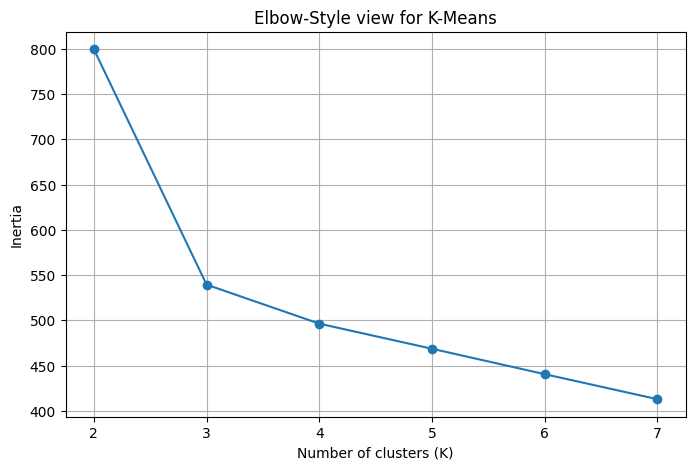

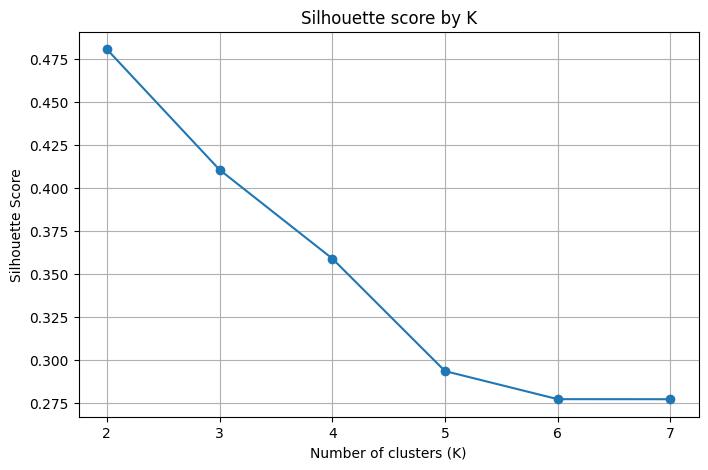

,K,Inertia,Silhouette
0,2,799.588003,0.480831
1,3,539.496511,0.410708
2,4,496.383627,0.359059
3,5,468.645889,0.293592
4,6,440.564580,0.277259
5,7,412.892056,0.277230


In [28]:
k_values = range(2, 8)
inertia_scores = []
silhouette_scores = []

for k in k_values:
  model = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = model.fit_predict(X_scaled)
  inertia_scores.append(model.inertia_)
  silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), inertia_scores, marker="o", label="Inertia")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow-Style view for K-Means")
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), silhouette_scores, marker="o")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette score by K")
ax.grid(True)
plt.show()

pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_scores,
    "Silhouette": silhouette_scores
})

In [29]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
students['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

students[["student_id", "kmeans_cluster"]].head()

,student_id,kmeans_cluster
0,S001,2
1,S002,2
2,S003,2
3,S004,2
4,S005,2


In [30]:
plot_df_db = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "dbscan_cluster": students['dbscan_cluster']
})

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(plot_df_db['PC1'], plot_df_db['PC2'], c=plot_df_db['dbscan_cluster'])
ax.set_title("DBSCAN results in PCA Space")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.grid(True)
plt.show()

KeyError: 'dbscan_cluster'

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca_2 = pca.fit_transform(X_scaled)


In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)  # You might need to tune eps and min_samples
students['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

plot_df_db = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "dbscan_cluster": students['dbscan_cluster']
})

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(plot_df_db['PC1'], plot_df_db['PC2'], c=plot_df_db['dbscan_cluster'])
ax.set_title("DBSCAN results in PCA Space")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.grid(True)
plt.show()

In [ ]:
noise_students = students.loc[students['dbscan_cluster'] == -1, ['student_id'] + feature_cols]
noise_students.head(10)

In [32]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cum_explained = explained_variance.cumsum()

pca_table = pd.DataFrame({
    "Principal Component": [f"PC{i}" for i in range(1, len(explained_variance)+1)],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cum_explained
})

pca_table

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.731640,0.731640
1,PC2,0.070427,0.802068
2,PC3,0.056023,0.858091
3,PC4,0.047324,0.905414
4,PC5,0.037725,0.943140
5,PC6,0.029444,0.972584
6,PC7,0.027416,1.000000


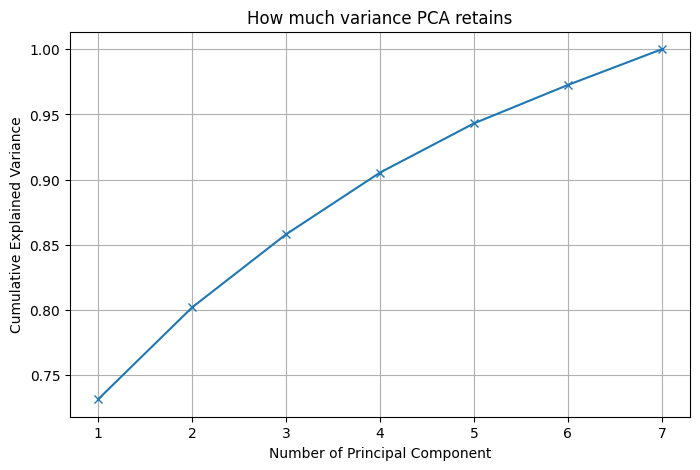

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(explained_variance)+1), cum_explained, marker="x")
ax.set_xlabel("Number of Principal Component")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("How much variance PCA retains")
ax.grid(True)
plt.show()

In [35]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index = feature_cols,
    columns = [f"PC{i}" for i in range(1, len(feature_cols)+1)]
).round(3)

loadings.iloc[:, :3]

,PC1,PC2,PC3
attendance_rate,0.386,-0.274,0.420
homework_completion,0.402,0.160,-0.075
quiz_average,0.379,-0.388,0.452
discussion_posts,0.368,0.462,0.057
login_days,0.383,0.291,0.161
missing_assignments,-0.374,-0.312,0.447
behavior_flags,-0.352,0.595,0.620


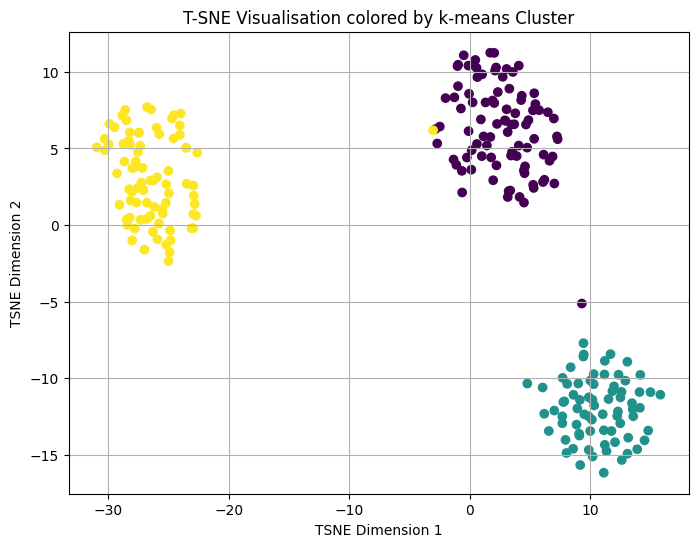

In [37]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "kmeans_cluster": students['kmeans_cluster']
})

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(tsne_df['TSNE1'], tsne_df['TSNE2'], c=tsne_df['kmeans_cluster'])
ax.set_title("T-SNE Visualisation colored by k-means Cluster")
ax.set_xlabel("TSNE Dimension 1")
ax.set_ylabel("TSNE Dimension 2")
ax.grid(True)
plt.show()
